In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [4]:
train_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|███████████████████████████| 26421880/26421880 [01:02<00:00, 424881.26it/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|█████████████████████████████████| 29515/29515 [00:00<00:00, 233089.72it/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|█████████████████████████████| 4422102/4422102 [00:05<00:00, 837515.01it/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|███████████████████████████████████| 5148/5148 [00:00<00:00, 457773.85it/s]

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



In [5]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x += residual
        return self.relu(x)

In [6]:
class AdvancedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = ResidualBlock(1, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.layer2 = ResidualBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.layer3 = ResidualBlock(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Sequential(
            nn.Linear(128*3*3, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

        self._initialize_weights()

    def forward(self, x):
        x = self.pool1(self.layer1(x))
        x = self.pool2(self.layer2(x))
        x = self.pool3(self.layer3(x))

        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)

In [7]:
model = AdvancedCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [8]:
def train(model, loader):
    model.train()
    running_loss = 0
    correct = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), correct / len(loader.dataset)

In [9]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)

            correct += predicted.eq(labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return correct / len(loader.dataset), all_preds, all_labels

In [10]:
epochs = 10

for epoch in range(epochs):
    train_loss, train_acc = train(model, train_loader)
    test_acc, preds, labels = evaluate(model, test_loader)

    scheduler.step()

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test Acc: {test_acc:.4f}")
    print("-"*40)

Epoch 1
Train Loss: 0.5437 | Train Acc: 0.8054
Test Acc: 0.8628
----------------------------------------
Epoch 2
Train Loss: 0.3661 | Train Acc: 0.8681
Test Acc: 0.8730
----------------------------------------
Epoch 3
Train Loss: 0.3203 | Train Acc: 0.8832
Test Acc: 0.9017
----------------------------------------
Epoch 4
Train Loss: 0.2928 | Train Acc: 0.8931
Test Acc: 0.9003
----------------------------------------
Epoch 5
Train Loss: 0.2694 | Train Acc: 0.9028
Test Acc: 0.9057
----------------------------------------
Epoch 6
Train Loss: 0.2523 | Train Acc: 0.9080
Test Acc: 0.9139
----------------------------------------
Epoch 7
Train Loss: 0.2343 | Train Acc: 0.9151
Test Acc: 0.9186
----------------------------------------
Epoch 8
Train Loss: 0.2243 | Train Acc: 0.9181
Test Acc: 0.9237
----------------------------------------
Epoch 9
Train Loss: 0.2135 | Train Acc: 0.9228
Test Acc: 0.9247
----------------------------------------
Epoch 10
Train Loss: 0.2069 | Train Acc: 0.9243
Test Ac

In [11]:
print(classification_report(labels, preds, target_names=train_dataset.classes))

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.89      0.88      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.88      0.91      0.89      1000
       Dress       0.92      0.93      0.93      1000
        Coat       0.89      0.89      0.89      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.80      0.76      0.77      1000
     Sneaker       0.95      0.98      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [12]:
train_losses = []
train_accuracies = []
val_accuracies = []

In [13]:
train_losses.append(train_loss)
train_accuracies.append(train_acc)
val_accuracies.append(test_acc)

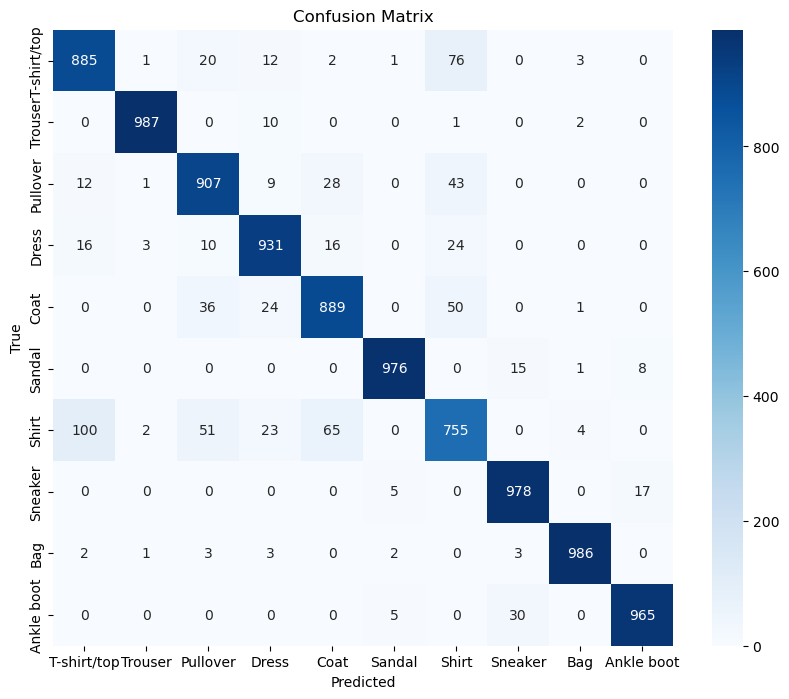

In [17]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

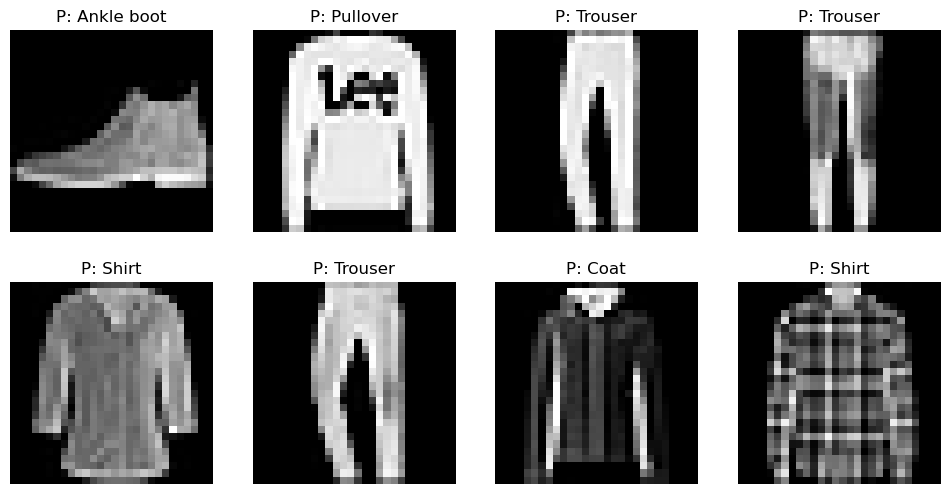

In [16]:
def show_predictions(model, loader):
    model.eval()
    images, labels = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    images = images.cpu()

    plt.figure(figsize=(12,6))
    for i in range(8):
        plt.subplot(2,4,i+1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title(f"P: {train_dataset.classes[preds[i]]}")
        plt.axis("off")

    plt.show()

show_predictions(model, test_loader)